# Exploratory Data Analysis (EDA) - Clothing, Shoes and Jewelry Dataset

Notebook này thực hiện phân tích khám phá dữ liệu (EDA) chi tiết cho tập dữ liệu **Amazon Reviews 2023 (Clothing, Shoes, and Jewelry)** đã được tiền xử lý dưới dạng các file Parquet trong thư mục `../data/`.

### Nội dung phân tích:
1. **Tổng quan về tập dữ liệu**: Kích thước, số lượng thực thể, độ thưa thớt (sparsity).
2. **Phân tích dữ liệu tương tác (Interactions)**: Phân phối Rating, Verified Purchase, hoạt động của User và độ phổ biến của Item.
3. **Phân tích yếu tố thời gian (Temporal Analysis)**: Sự thay đổi tương tác theo thời gian.
4. **Phân tích Metadata sản phẩm (Items)**: Phân phối danh mục (Category), thương hiệu (Brand), giá cả (Price), chất lượng văn bản và hình ảnh.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

DATA_DIR = "../data/"
print("Các file trong thư mục data:", os.listdir(DATA_DIR))

Các file trong thư mục data: ['dataset_manifest.json', 'items.parquet', 'test.parquet', 'train.parquet', 'valid.parquet']


## 1. Đọc Dataset Manifest & Load dữ liệu

In [2]:
# Đọc manifest
manifest_path = os.path.join(DATA_DIR, "dataset_manifest.json")
with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print("=== DATASET MANIFEST ===")
print(json.dumps(manifest, indent=2, ensure_ascii=False))

# Load các tập Parquet
train_df = pd.read_parquet(os.path.join(DATA_DIR, "train.parquet"))
valid_df = pd.read_parquet(os.path.join(DATA_DIR, "valid.parquet"))
test_df = pd.read_parquet(os.path.join(DATA_DIR, "test.parquet"))
items_df = pd.read_parquet(os.path.join(DATA_DIR, "items.parquet"))

print("\n=== KÍCH THƯỚC CÁC BẢNG DỮ LIỆU ===")
print(f"Train interactions: {train_df.shape}")
print(f"Valid interactions: {valid_df.shape}")
print(f"Test interactions:  {test_df.shape}")
print(f"Item Metadata:      {items_df.shape}")

=== DATASET MANIFEST ===
{
  "source": "Amazon Reviews 2023 / Clothing_Shoes_and_Jewelry",
  "method": "two-pass streamed stable-hash user pool; activity strata; full histories; iterative k-core; chronological leave-last-out",
  "seed": "20260813",
  "target_users": 30000,
  "target_interactions": 350000,
  "counts": [
    {
      "split": "valid",
      "rows": 12134,
      "users": 12134,
      "items": 9051
    },
    {
      "split": "train",
      "rows": 89387,
      "users": 12134,
      "items": 30226
    },
    {
      "split": "test",
      "rows": 12134,
      "users": 12134,
      "items": 8890
    }
  ]
}

=== KÍCH THƯỚC CÁC BẢNG DỮ LIỆU ===
Train interactions: (89387, 5)
Valid interactions: (12134, 5)
Test interactions:  (12134, 5)
Item Metadata:      (31368, 8)


## 2. Tính toán độ thưa thớt (Sparsity) và Thống kê tổng quan
Độ thưa thớt là đặc tính quan trọng nhất của hệ thống gợi ý, ảnh hưởng lớn đến thiết kế của mô hình.

In [3]:
num_users = train_df["user_id"].nunique()
num_items = items_df["item_id"].nunique()
total_interactions = len(train_df) + len(valid_df) + len(test_df)

sparsity = 1.0 - (total_interactions / (num_users * num_items))
density = (total_interactions / (num_users * num_items)) * 100

print(f"Số lượng User duy nhất: {num_users:,}")
print(f"Số lượng Item duy nhất: {num_items:,}")
print(f"Tổng số tương tác (Train + Valid + Test): {total_interactions:,}")
print(f"Mật độ dữ liệu (Density): {density:.5f}%")
print(f"Độ thưa thớt dữ liệu (Sparsity): {sparsity * 100:.5f}%")

Số lượng User duy nhất: 12,134
Số lượng Item duy nhất: 31,368
Tổng số tương tác (Train + Valid + Test): 113,655
Mật độ dữ liệu (Density): 0.02986%
Độ thưa thớt dữ liệu (Sparsity): 99.97014%


## 3. Phân tích Dữ liệu Tương tác (Interactions)

### 3.1. Phân phối Rating
Xem xét phân phối rating giữa các tập split để xem mức độ lệch nhãn.

[16:29:38] INFO     Using categorical units to plot a list of   category.py:224
                    strings that are all parsable as floats or                 
                    dates. If these strings should be plotted                  
                    as numbers, cast to the appropriate data                   
                    type before plotting.                                      
           INFO     Using categorical units to plot a list of   category.py:224
                    strings that are all parsable as floats or                 
                    dates. If these strings should be plotted                  
                    as numbers, cast to the appropriate data                   
                    type before plotting.                                      


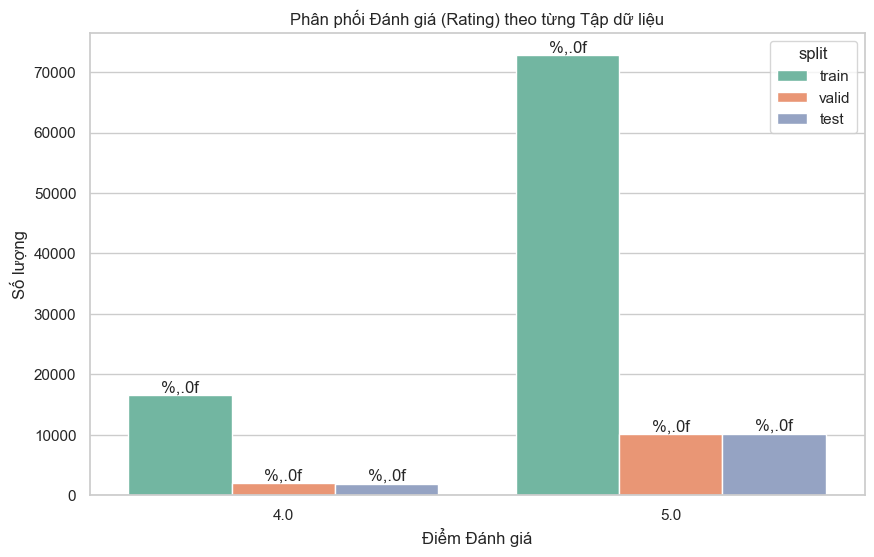

In [4]:
train_df["split"] = "train"
valid_df["split"] = "valid"
test_df["split"] = "test"
all_interactions = pd.concat([train_df, valid_df, test_df], ignore_index=True)

ax = sns.countplot(data=all_interactions, x="rating", hue="split", palette="Set2")
plt.title("Phân phối Đánh giá (Rating) theo từng Tập dữ liệu")
plt.xlabel("Điểm Đánh giá")
plt.ylabel("Số lượng")
for container in ax.containers:
    ax.bar_label(container, fmt='%,.0f')
plt.show()

### 3.2. Tỷ lệ xác thực mua hàng (Verified Purchase)
Xác định độ tin cậy của các đánh giá.

Tỷ lệ Verified Purchase theo từng tập split:
split
test     93.50
train    88.43
valid    93.79%
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ FutureWarning in                                                            │
│ C:\Users\Admin\AppData\Local\Temp\ipykernel_27868\418895479.py:5            │
│                                                                             │
│                                                                             │
│ Passing `palette` without assigning `hue` is deprecated and will be removed │
│ in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the │
│ same effect.                                                                │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘


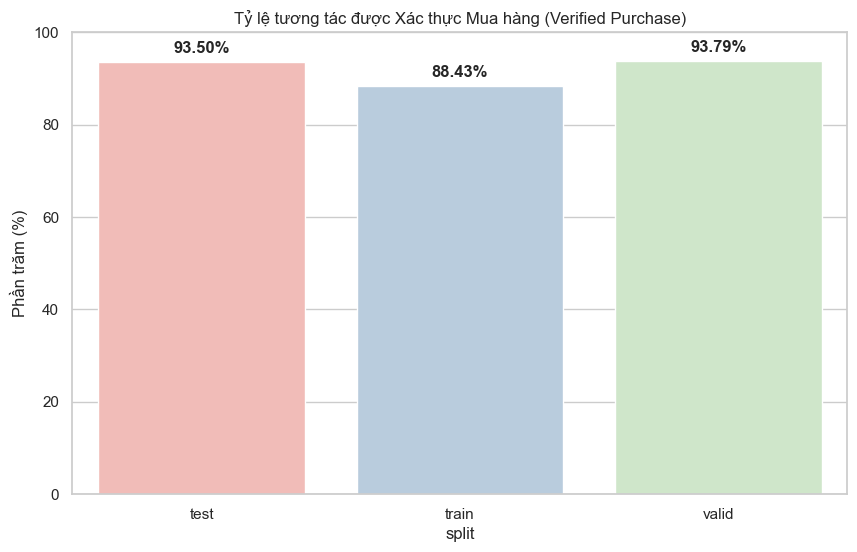

In [5]:
verified_pct = all_interactions.groupby("split")["verified_purchase"].mean() * 100
print("Tỷ lệ Verified Purchase theo từng tập split:")
print(verified_pct.round(2).to_string() + "%")

sns.barplot(x=verified_pct.index, y=verified_pct.values, palette="Pastel1")
plt.title("Tỷ lệ tương tác được Xác thực Mua hàng (Verified Purchase)")
plt.ylabel("Phần trăm (%)")
plt.ylim(0, 100)
for i, val in enumerate(verified_pct.values):
    plt.text(i, val + 2, f"{val:.2f}%", ha="center", fontweight="bold")
plt.show()

### 3.3. Phân phối số lượng tương tác của User (User Activity Strata)
Tìm hiểu xem có bao nhiêu tương tác trung bình trên mỗi người dùng.

Thống kê số tương tác trên mỗi User:
count    12134.000000
mean         9.366656
std          7.601668
min          5.000000
25%          5.000000
50%          7.000000
75%         11.000000
max        211.000000
dtype: float64


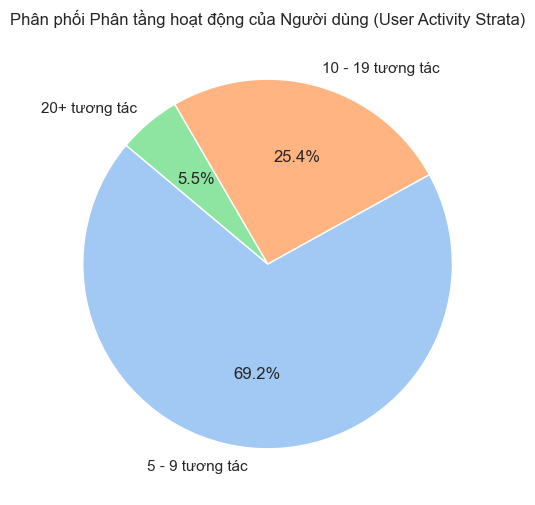

In [6]:
user_counts = all_interactions.groupby("user_id").size()
print("Thống kê số tương tác trên mỗi User:")
print(user_counts.describe())

# Phân nhóm mức độ hoạt động
def activity_band(n):
    if n <= 9: return "5 - 9 tương tác"
    elif n <= 19: return "10 - 19 tương tác"
    else: return "20+ tương tác"

user_bands = user_counts.apply(activity_band).value_counts().reindex(["5 - 9 tương tác", "10 - 19 tương tác", "20+ tương tác"])
plt.pie(user_bands.values, labels=user_bands.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Phân phối Phân tầng hoạt động của Người dùng (User Activity Strata)")
plt.show()

### 3.4. Phân phối độ phổ biến của Item (Long Tail Distribution)
Hầu hết các hệ thống gợi ý đều đối mặt với hiện tượng "đuôi dài" - một số lượng rất ít mặt hàng chiếm phần lớn lượt tương tác.

Thống kê lượt tương tác trên mỗi Item:
count    31368.000000
mean         3.623279
std          6.370635
min          2.000000
25%          2.000000
50%          2.000000
75%          4.000000
max        907.000000
dtype: float64


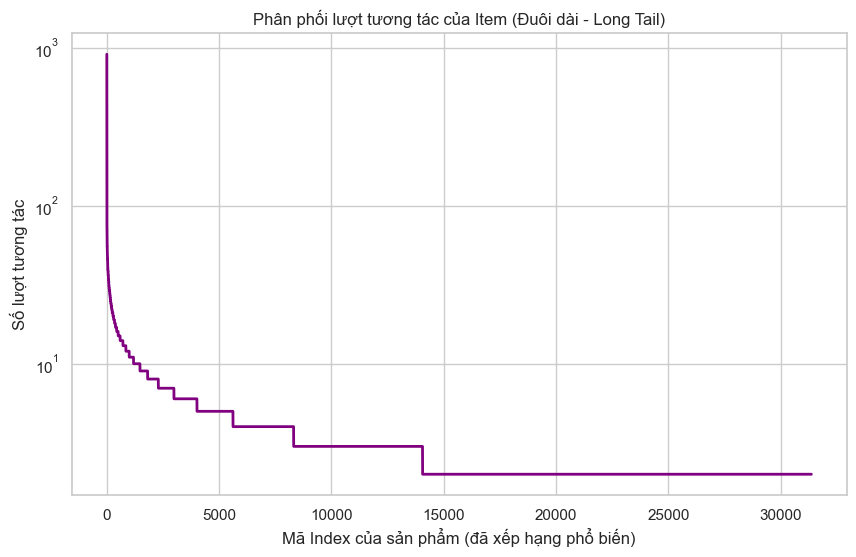

In [7]:
item_counts = all_interactions.groupby("item_id").size().sort_values(ascending=False)
print("Thống kê lượt tương tác trên mỗi Item:")
print(item_counts.describe())

plt.plot(item_counts.values, color='purple', linewidth=2)
plt.title("Phân phối lượt tương tác của Item (Đuôi dài - Long Tail)")
plt.xlabel("Mã Index của sản phẩm (đã xếp hạng phổ biến)")
plt.ylabel("Số lượt tương tác")
plt.yscale("log")  # sử dụng log scale cho trục y để dễ nhìn
plt.show()

## 4. Phân tích yếu tố thời gian (Temporal Analysis)
Xem xét xu hướng tương tác tích cực thay đổi như thế nào qua các năm.

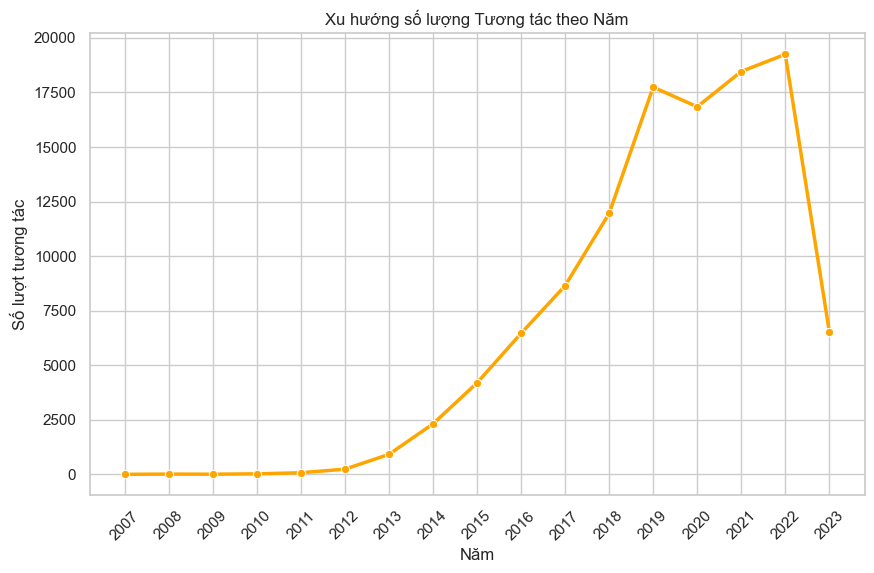

In [8]:
# Chuyển đổi timestamp thành Datetime
all_interactions["date"] = pd.to_datetime(all_interactions["timestamp"], unit="ms")
all_interactions["year"] = all_interactions["date"].dt.year

year_counts = all_interactions["year"].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", color="orange", linewidth=2.5)
plt.title("Xu hướng số lượng Tương tác theo Năm")
plt.xlabel("Năm")
plt.ylabel("Số lượt tương tác")
plt.xticks(year_counts.index, rotation=45)
plt.show()

## 5. Phân tích Metadata Sản phẩm (`items.parquet`)

### 5.1. Phân phối Danh mục sản phẩm (Main Categories)

┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ FutureWarning in                                                            │
│ C:\Users\Admin\AppData\Local\Temp\ipykernel_27868\971654456.py:15           │
│                                                                             │
│                                                                             │
│ Passing `palette` without assigning `hue` is deprecated and will be removed │
│ in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the │
│ same effect.                                                                │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘


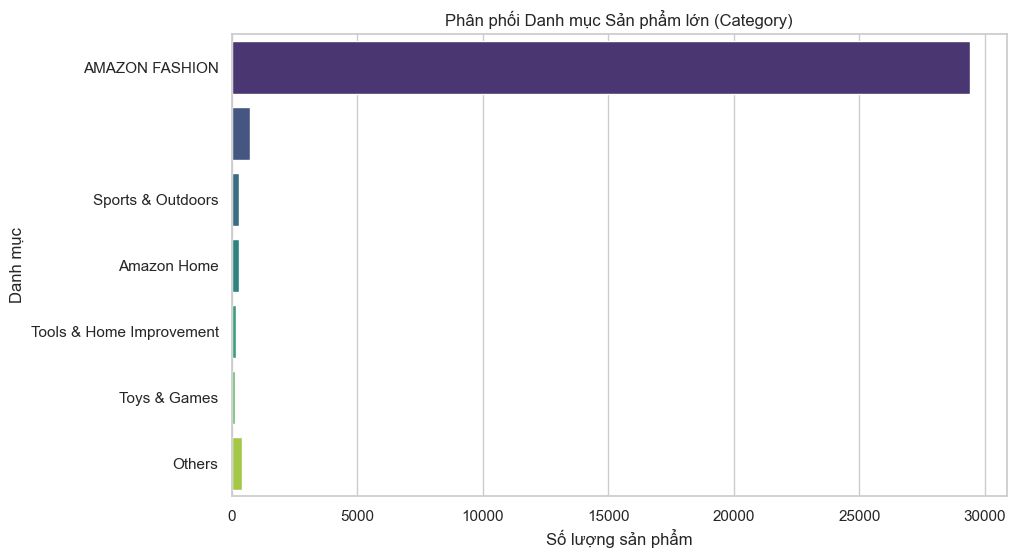

In [9]:
cat_counts = items_df["category"].value_counts()
cat_counts_df = pd.DataFrame({"Category": cat_counts.index, "Count": cat_counts.values})

# Nhóm các danh mục nhỏ vào 'Others'
threshold = 100
small_cats = cat_counts_df[cat_counts_df["Count"] < threshold]["Count"].sum()
cat_counts_filtered = cat_counts_df[cat_counts_df["Count"] >= threshold]
if small_cats > 0:
    # Sử dụng concat thay vì append đã bị deprecate trong pandas mới
    cat_counts_filtered = pd.concat([
        cat_counts_filtered,
        pd.DataFrame([{"Category": "Others", "Count": small_cats}])
    ], ignore_index=True)

sns.barplot(data=cat_counts_filtered, y="Category", x="Count", palette="viridis")
plt.title("Phân phối Danh mục Sản phẩm lớn (Category)")
plt.xlabel("Số lượng sản phẩm")
plt.ylabel("Danh mục")
plt.show()

### 5.2. Thương hiệu lớn (Top Brands)

Tổng số thương hiệu duy nhất: 10,365
Số sản phẩm thiếu thông tin thương hiệu: 62 (0.20%)
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ FutureWarning in                                                            │
│ C:\Users\Admin\AppData\Local\Temp\ipykernel_27868\2426023128.py:5           │
│                                                                             │
│                                                                             │
│ Passing `palette` without assigning `hue` is deprecated and will be removed │
│ in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the │
│ same effect.                                                                │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘


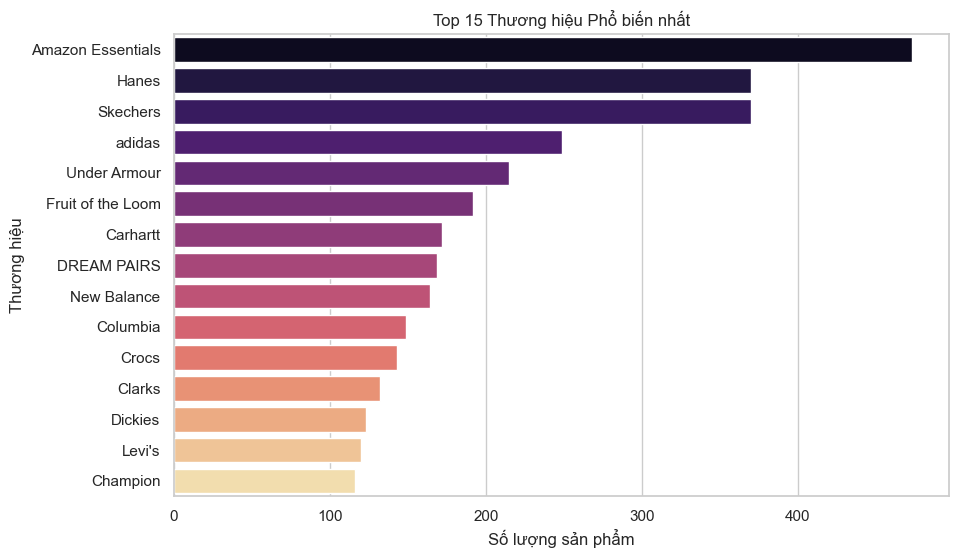

In [10]:
print(f"Tổng số thương hiệu duy nhất: {items_df['brand'].nunique():,}")
print(f"Số sản phẩm thiếu thông tin thương hiệu: {items_df['brand'].isnull().sum():,} ({items_df['brand'].isnull().sum()/len(items_df)*100:.2f}%)")

top_brands = items_df["brand"].value_counts().head(15)
sns.barplot(y=top_brands.index, x=top_brands.values, palette="magma")
plt.title("Top 15 Thương hiệu Phổ biến nhất")
plt.xlabel("Số lượng sản phẩm")
plt.ylabel("Thương hiệu")
plt.show()

### 5.3. Phân phối Giá bán (Price Distribution)
Giá sản phẩm có thể ảnh hưởng lớn đến quyết định mua hàng của người dùng.

Thống kê mô tả về Giá sản phẩm:
count    26566.000000
mean        31.539848
std         34.181537
min          0.010000
25%         16.990000
50%         24.990000
75%         36.400000
max       3369.000000
Name: price, dtype: float64


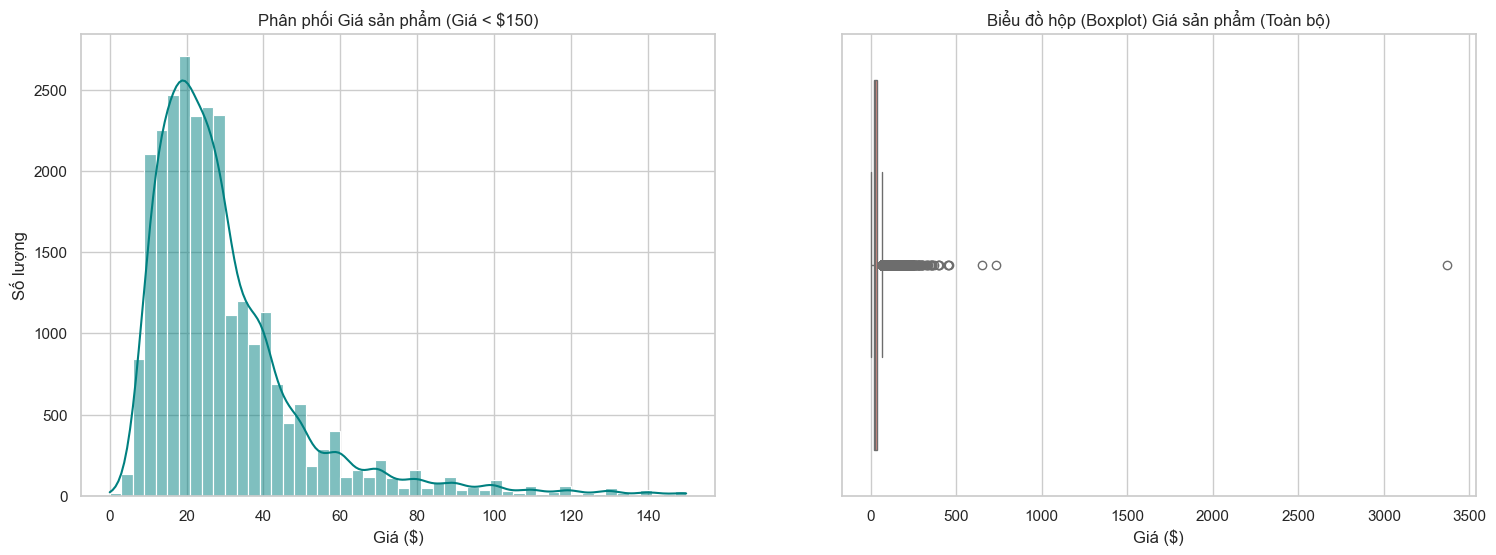

In [11]:
valid_prices = items_df["price"].dropna()
print("Thống kê mô tả về Giá sản phẩm:")
print(valid_prices.describe())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Phân phối tổng quan giới hạn giá < $150
sns.histplot(valid_prices[valid_prices < 150], bins=50, kde=True, ax=ax1, color="teal")
ax1.set_title("Phân phối Giá sản phẩm (Giá < $150)")
ax1.set_xlabel("Giá ($)")
ax1.set_ylabel("Số lượng")

# Boxplot để xem outliers
sns.boxplot(x=valid_prices, ax=ax2, color="salmon")
ax2.set_title("Biểu đồ hộp (Boxplot) Giá sản phẩm (Toàn bộ)")
ax2.set_xlabel("Giá ($)")
plt.show()

### 5.4. Chiều dài Văn bản (Text Length distribution)
Vì đây là hệ thống gợi ý đa phương thức (Multimodal), chiều dài và chất lượng của đặc trưng văn bản đóng vai trò quan trọng trong việc học embedding.

Chiều dài văn bản trung bình:
- Title:       82.0 ký tự
- Description: 250.6 ký tự
- Features:    730.3 ký tự


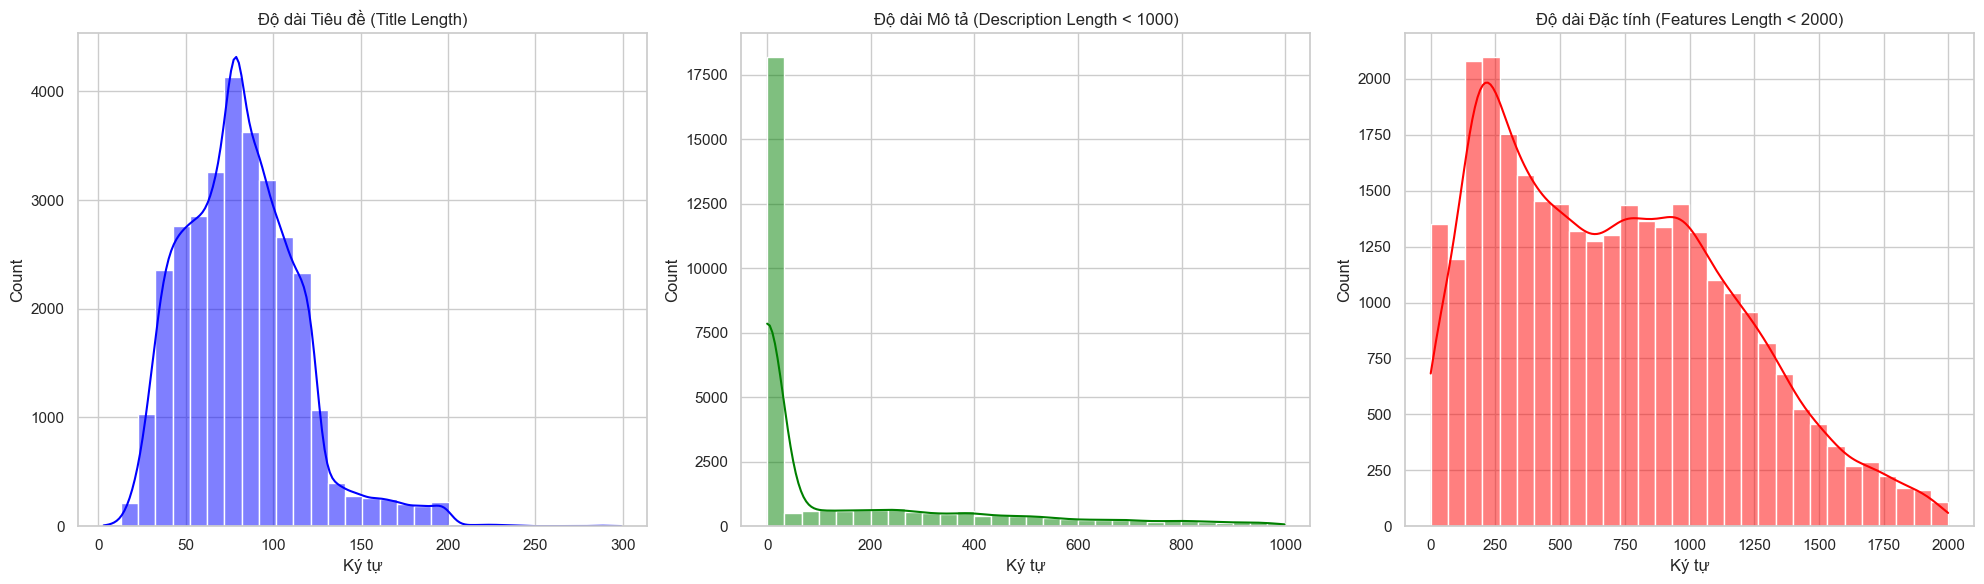

In [12]:
items_df["title_len"] = items_df["title"].str.len()
items_df["desc_len"] = items_df["description"].str.len()
items_df["feat_len"] = items_df["features"].str.len()

print("Chiều dài văn bản trung bình:")
print(f"- Title:       {items_df['title_len'].mean():.1f} ký tự")
print(f"- Description: {items_df['desc_len'].mean():.1f} ký tự")
print(f"- Features:    {items_df['feat_len'].mean():.1f} ký tự")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.histplot(items_df["title_len"], bins=30, ax=axes[0], color="blue", kde=True)
axes[0].set_title("Độ dài Tiêu đề (Title Length)")
axes[0].set_xlabel("Ký tự")

sns.histplot(items_df[items_df["desc_len"] < 1000]["desc_len"], bins=30, ax=axes[1], color="green", kde=True)
axes[1].set_title("Độ dài Mô tả (Description Length < 1000)")
axes[1].set_xlabel("Ký tự")

sns.histplot(items_df[items_df["feat_len"] < 2000]["feat_len"], bins=30, ax=axes[2], color="red", kde=True)
axes[2].set_title("Độ dài Đặc tính (Features Length < 2000)")
axes[2].set_xlabel("Ký tự")

plt.tight_layout()
plt.show()

### 5.5. Kiểm tra chất lượng Ảnh sản phẩm (Image Quality)
Một trong các cấu phần đa phương thức quan trọng nhất là Hình ảnh sản phẩm.

In [13]:
missing_images = items_df["image_url"].isnull().sum()
total_items = len(items_df)
print(f"Số sản phẩm thiếu URL ảnh: {missing_images} / {total_items} ({missing_images/total_items*100:.3f}%)")

# Hiển thị ngẫu nhiên 5 ảnh đầu tiên để kiểm tra
print("\nVí dụ 5 link ảnh sản phẩm:")
for idx, url in enumerate(items_df["image_url"].dropna().head(5)):
    print(f"{idx+1}. {url}")

Số sản phẩm thiếu URL ảnh: 7 / 31368 (0.022%)

Ví dụ 5 link ảnh sản phẩm:
1. https://m.media-amazon.com/images/I/31ntcDSaCrL._AC_.jpg
2. https://m.media-amazon.com/images/I/31Ly1kzrr4L._AC_.jpg
3. https://m.media-amazon.com/images/I/31P6tzEWByL._AC_.jpg
4. https://m.media-amazon.com/images/I/31fCkEUsY9L._AC_.jpg
5. https://m.media-amazon.com/images/I/41eE6Qmf7WL._AC_.jpg


## 6. Kết luận rút ra cho việc thiết kế mô hình Multimodal Recommender

1. **Thiết kế Loss Function**: Do tập dữ liệu thưa thớt (Sparsity ~99.97%), nên sử dụng mô hình tối ưu theo cặp **Bayesian Personalized Ranking (BPR)** hoặc các loss liên quan đến **Contrastive Learning** thay vì MSE thông thường.
2. **Xử lý thiếu thông tin (Missing Values)**:
   - Có **15.31%** sản phẩm bị thiếu giá. Cần impute bằng median ($24.99) hoặc giá trị trung bình thương hiệu trước khi đưa vào mô hình.
   - Đối với **7** sản phẩm khuyết ảnh, cần sử dụng một vector đặc trưng ảnh mặc định (được khởi tạo ngẫu nhiên hoặc zero vector) khi trích xuất đặc trưng.
3. **Khai thác dữ liệu văn bản**:
   - Tiêu đề sản phẩm khá ngắn (trung bình 82 ký tự) và sạch sẽ, thích hợp làm đầu vào cho các mô hình trích xuất đặc trưng nhẹ (như Sentence-BERT hoặc các Text Encoder nhỏ).
   - Trường `features` chứa thông tin cực kỳ phong phú và dài (trung bình 730 ký tự), có thể kết hợp với `description` để xây dựng RAG hoặc hỗ trợ đắc lực cho biểu diễn sản phẩm.